# 17 - Demonstration of Quantum Annealing with FQAOA

The framework of Fermionic QAOA (FQAOA) covers the Quantum Annealing (QA) framework [1]. In this note, we demonstrate that QA with FQAOA works for constrained combinatorial optimisation problems in practice and compare its performance with QA with conventional QAOA [2].

## FQAOA Ansatz for QA
FQAOA supports a discretised form of quantum annealing.
Quantum annealing starts with a mixer Hamiltonian ground state and gradually evolves to a cost Hamiltonian ground state.
If the transformation can be performed slowly to infinity, it is guaranteed to reach the exact ground state of the cost Hamiltonian.
In practice, the transformation is performed over a finite time and we want to prepare the ground state with some high probability.

The approximated ground state obtained by QA are as follows:
$$|\psi(T)\rangle = {\cal T}\exp\left\{ -i\int_0^T \left[\left(1-\frac{t}{T}\right)\hat{\cal H}_M+\frac{t}{T}\hat{\cal H}_C\right] dt\right\}\hat{U}_{\rm init}|{\rm vac}\rangle,$$
where the cost $\hat{\cal H}_C$ and mixer $\hat{\cal H}_M$ Hamiltonians, and initial state preparation unitary $\hat{U}_{\rm init}$ are given in the notebook (16_FQAOA_examples.ipynb)[./16_FQAOA_examples.ipynb]. $T$ is annealing time and $\cal T$ is time ordering product for $t$.

The $|\psi(T)\rangle$ is approximated in the following form for calculation in quantum circuits [1, 2]:
$$|\psi(T)\rangle\sim|\psi_p({\boldsymbol \gamma}^{(0)}, {\boldsymbol \beta}^{(0)})\rangle 
= \left[\prod_{j=1}^pU(\hat{\cal H}_M,\beta_j^{(0)}){U}(\hat{\cal H}_C,\gamma_j^{(0)})\right]\hat{U}_{\rm init}|{\rm vac}\rangle,$$
with
\begin{eqnarray}
  \gamma_j^{(0)} &=& \frac{2j-1}{2p}\Delta t, \\
  \beta_j^{(0)}  &=& \left(1-\frac{2j-1}{2p}\right)\Delta t,
\end{eqnarray}
where $\Delta t$ is the unit of descretized annealing time, as $T=p\Delta t$.

In the FQAOA ansatz, the following constraints can be imposed on any integer $M$ smaller than the number of qubits $N$ as:
$$\sum_{i=1}^{N} \hat{n}_i|\psi_p({\boldsymbol \gamma^{(0)}}, {\boldsymbol \beta}^{(0)})\rangle = M|\psi_p({\boldsymbol \gamma^{(0)}}, {\boldsymbol \beta}^{(0)})\rangle,$$
where $\hat{n}_i = \hat{c}^\dagger_i\hat{c}_i$ is number operator and $\hat{c}_i^\dagger (\hat{c}_i)$ is creation (annihilation) operator of fermion at $i$-th site.

The FQAOA ansatz is also improved from $|\psi_p({\boldsymbol \gamma}^{(0)}, {\boldsymbol \beta}^{(0)})\rangle$ by setting ${\boldsymbol \gamma}^{(0)}, {\boldsymbol \beta}^{(0)}$ as initial parameters and running FQAOA. Thus, the performance of the FQAOA framework is guaranteed by QA.


In [8]:
%matplotlib notebook
%matplotlib inline

# Import the libraries needed to employ the QAOA and FQAOA quantum algorithm using OpenQAOA
from openqaoa import FQAOA
from openqaoa import QAOA

# method to covnert a docplex model to a qubo problem
from openqaoa.problems import PortfolioOptimization
from openqaoa.backends import create_device
from openqaoa.algorithms.fqaoa import fqaoa_utils

# Import external libraries to present an manipulate the data
import numpy as np
import matplotlib.pyplot as plt

# Indicate the device, this case is a local simulator
device = create_device('local', 'vectorized')

In the following, the [portfolio optimization problem](https://en.wikipedia.org/wiki/Portfolio_optimization) is taken as a constrained quadratic formal optimisation problem.
In this case, $N$ and $M$ in the equation are the number of the assets and the budget, respectively.

## Create a Problem Instance

To simplify the problem, it is used a random function to generate the predictions the expected return for 10 assets during 15 days as in [6]. 

In [9]:
# generate the input data for portfolio optimization
num_assets = 4 # number of assets
budget = 2 # budget constraint value
num_days = 15 # number of days
seed = 1 # seed of random number
mu, sigma, hist_exp = fqaoa_utils.generate_random_portfolio_data(num_assets, num_days, seed)
problem = PortfolioOptimization(mu, sigma, risk_factor = None, budget = budget, penalty = None).qubo

## Execute Quantum Annealing

Here, a fermionic mixer Hamiltonian $\hat{\cal H}_M$ on cyclic lattice determines its ground state as the initial state $\hat{U}_{\rm init}|\rm vac\rangle$ and its mixer $U(\hat{\cal H}_M, \beta)$.

In [10]:
# QA using FQAOA
fqaoa_cost_list = []
fqaoa_ip_values = range(1, 21)
fqaoa_dt = 0.1

for ip in fqaoa_ip_values:
    fqaoa = FQAOA(device)
    fqaoa.set_circuit_properties(p=ip, param_type='annealing', init_type='ramp', annealing_time=fqaoa_dt*ip)
    fqaoa.set_classical_optimizer(maxiter=0)
    fqaoa.fermi_compile(problem = problem, n_fermions = budget)
    fqaoa.optimize()
    fqaoa_cost_list.append(fqaoa.result.optimized['cost'])

Here, the conventional X-mixer Hamiltonian $H_M$ determines its ground state as the initial state and its unitary transformation $\exp(-i\beta\hat{\cal H}_M)$ as the mixer.

In [11]:
# QA using QAOA
qaoa_cost_list = []
qaoa_ip_values = range(1, 101)
qaoa_dt = 0.01

for ip in qaoa_ip_values:
    qaoa = QAOA(device)
    qaoa.set_circuit_properties(p=ip, param_type='annealing', init_type='ramp', annealing_time=qaoa_dt*ip)
    qaoa.set_classical_optimizer(maxiter=0)
    qaoa.compile(problem = problem)
    qaoa.optimize()
    qaoa_cost_list.append(qaoa.result.optimized['cost'])

## Plotting the Results and Comparison

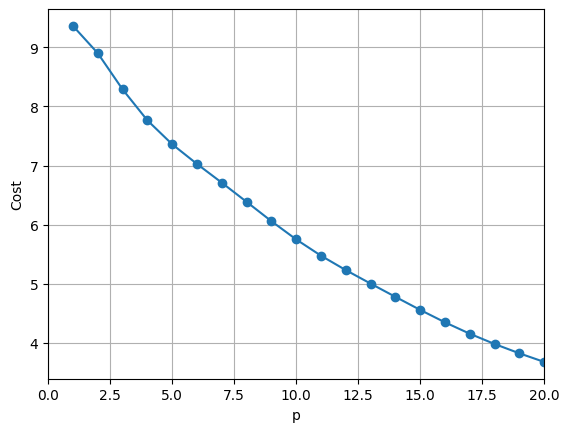

In [12]:
# Plotting the FQAOA results
plt.plot(fqaoa_ip_values, fqaoa_cost_list, marker='o')
plt.xlabel('p')
plt.ylabel('Cost')
plt.xlim(0, 20)
plt.grid(True)
plt.show()

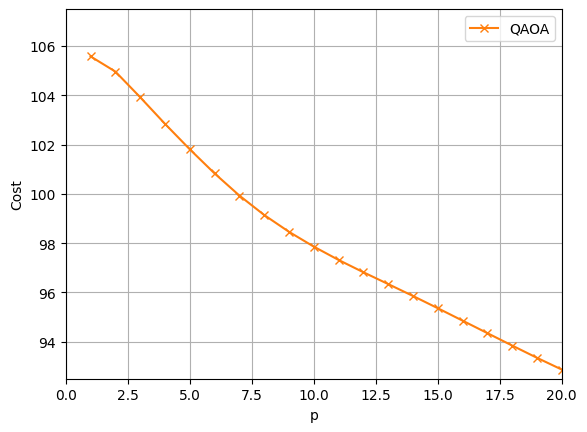

In [13]:
# Plotting the QAOA results
plt.plot(qaoa_ip_values, qaoa_cost_list, marker='x', label='QAOA', color='C1')
plt.xlabel('p')
plt.ylabel('Cost')
plt.xlim(0, 20)
plt.ylim(92.5,107.5)
plt.grid(True)
plt.legend()
plt.show()

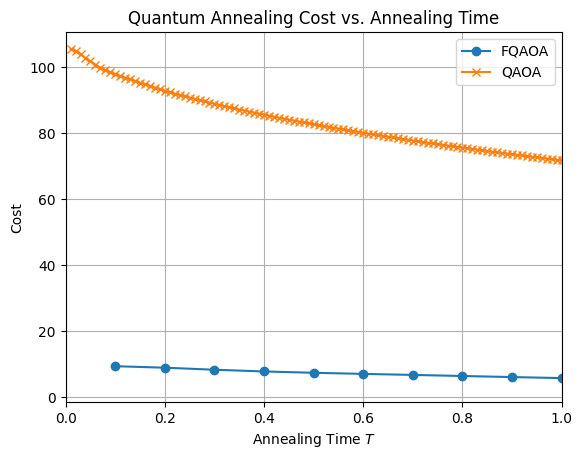

In [14]:
# Plotting costs against annealing time
fqaoa_annealing_times = [ip * 0.1 for ip in fqaoa_ip_values]
qaoa_annealing_times = [ip * 0.01 for ip in qaoa_ip_values]

# Plotting the results
plt.plot(fqaoa_annealing_times, fqaoa_cost_list, marker='o', label='FQAOA')
plt.plot(qaoa_annealing_times, qaoa_cost_list, marker='x', label='QAOA')
plt.xlabel('Annealing Time $T$')
plt.ylabel('Cost')
plt.title(r'Quantum Annealing Cost vs. Annealing Time')
plt.xlim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

# References
[1] T. Yoshioka, K. Sasada, Y. Nakano, and K. Fujii, [Phys. Rev. Research 5, 023071 (2023).](https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.5.023071), [arXiv: 2301.10756 [quant-ph]](https://arxiv.org/pdf/2301.10756).\
[2] E. Farhi, J. Goldston, S. Gutmann, M. Sipser, [arXiv:quant-ph/0001106](https://arxiv.org/pdf/quant-ph/0001106).